Course: Generative AI Lab   
Class: T.Y. B.Tech  
Student Name: Mansi Somani  
PRN Number: 20240111005  
Batch: A1  
Date of Submission: 15-08-2026

## Objective

Implement a simple feedforward neural network from scratch in Python without using
built-in deep learning libraries. The implementation demonstrates the forward pass,
backpropagation, loss calculation, and training using gradient descent.

In [1]:
# Wine Cultivar Classification using a Feedforward Neural Network from Scratch

import numpy as np
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt

Training Accuracy: 100.0
Testing Accuracy : 97.22222222222221
Training Loss    : 0.014594893665452727
Testing Loss     : 0.048668236271253815
Training F1      : 100.0
Testing F1       : 97.19701552732407
Test Precision   : 97.4074074074074
Test Recall      : 97.22222222222221
\nConfusion Matrix:\n [[12  0  0]
 [ 0 14  0]
 [ 0  1  9]]


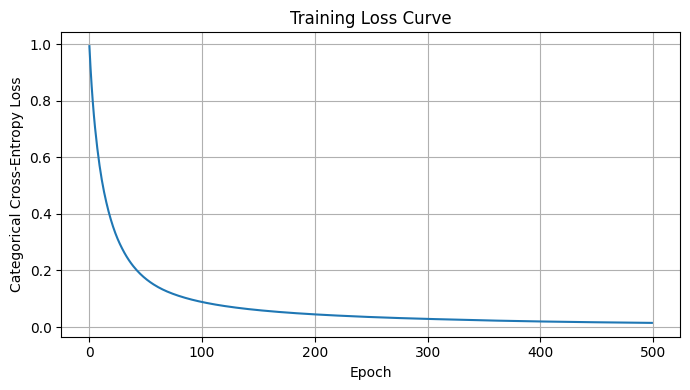

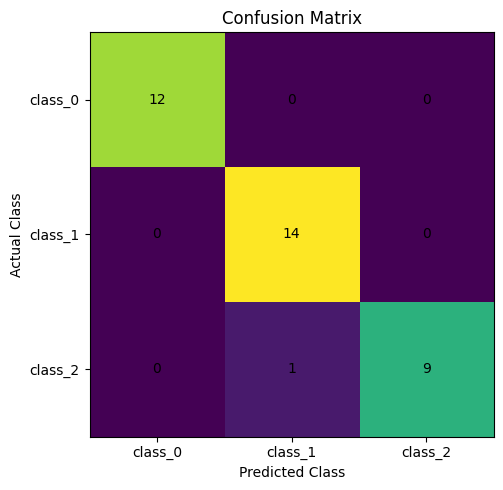

In [3]:
data = load_wine()
X = data.data.astype(float)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0)
X_train = (X_train - mu) / (sigma + 1e-8)
X_test = (X_test - mu) / (sigma + 1e-8)

Y_train = np.eye(3)[y_train]
Y_test = np.eye(3)[y_test]

rng = np.random.default_rng(42)
W1 = rng.normal(0, np.sqrt(2 / 13), (13, 10))
b1 = np.zeros((1, 10))
W2 = rng.normal(0, np.sqrt(2 / (10 + 3)), (10, 3))
b2 = np.zeros((1, 3))

def relu(Z):
    return np.maximum(0, Z)

def relu_derivative(Z):
    return (Z > 0).astype(float)

def softmax(Z):
    exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

def forward_pass(X, W1, b1, W2, b2):
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)
    Z2 = np.dot(A1, W2) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def categorical_cross_entropy(Y, A2):
    return -np.mean(np.sum(Y * np.log(A2 + 1e-15), axis=1))

def backward_pass(X, Y_onehot, Z1, A1, A2, W2):
    m = X.shape[0]

    dZ2 = A2 - Y_onehot
    dW2 = (1 / m) * np.dot(A1.T, dZ2)
    db2 = (1 / m) * np.sum(dZ2, axis=0, keepdims=True)

    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * relu_derivative(Z1)

    dW1 = (1 / m) * np.dot(X.T, dZ1)
    db1 = (1 / m) * np.sum(dZ1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2

learning_rate = 0.05
epochs = 500
loss_history = []

for epoch in range(epochs):
    Z1, A1, Z2, A2 = forward_pass(X_train, W1, b1, W2, b2)
    loss = categorical_cross_entropy(Y_train, A2)
    loss_history.append(loss)

    dW1, db1, dW2, db2 = backward_pass(
        X_train, Y_train, Z1, A1, A2, W2
    )

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

_, _, _, train_prob = forward_pass(X_train, W1, b1, W2, b2)
_, _, _, test_prob = forward_pass(X_test, W1, b1, W2, b2)

train_pred = np.argmax(train_prob, axis=1)
test_pred = np.argmax(test_prob, axis=1)

print("Training Accuracy:", accuracy_score(y_train, train_pred) * 100)
print("Testing Accuracy :", accuracy_score(y_test, test_pred) * 100)
print("Training Loss    :", categorical_cross_entropy(Y_train, train_prob))
print("Testing Loss     :", categorical_cross_entropy(Y_test, test_prob))
print("Training F1      :", f1_score(y_train, train_pred, average="weighted") * 100)
print("Testing F1       :", f1_score(y_test, test_pred, average="weighted") * 100)
print("Test Precision   :", precision_score(y_test, test_pred, average="weighted") * 100)
print("Test Recall      :", recall_score(y_test, test_pred, average="weighted") * 100)
print("\\nConfusion Matrix:\\n", confusion_matrix(y_test, test_pred))

plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Categorical Cross-Entropy Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test, test_pred)
plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.xticks([0, 1, 2], data.target_names)
plt.yticks([0, 1, 2], data.target_names)

for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()